In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [ ]:
df= pd.read_csv("housing_cleaned.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
y= df["median_house_value"]
X= df.drop("median_house_value", axis=1)
#training and test split
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.25,
)

In [ ]:
scaler= StandardScaler()

#create copies to avoid modifying the original X_train and X_test in place repeatedly
# which causes the KeyError if cell is run multiple times without resetting
X_train_temp= X_train.copy()
X_test_temp= X_test.copy()

#one hot encode (categorical 'ocean_proximity'into binary)
if 'ocean_proximity' in X_train_temp.columns:
    X_train_temp= pd.get_dummies(X_train_temp, columns=['ocean_proximity'], drop_first=True)
if 'ocean_proximity' in X_test_temp.columns:
    X_test_temp= pd.get_dummies(X_test_temp, columns=['ocean_proximity'], drop_first=True)

#align columns for consistency after one hot encoding
X_test_temp= X_test_temp.reindex(columns=X_train_temp.columns, fill_value=0)

X_train_scaled= scaler.fit_transform(X_train_temp)
X_test_scaled= scaler.transform(X_test_temp)

In [ ]:
model= LinearRegression() #linear regression attributes
model.fit(X_train_scaled, y_train)
y_pred= model.predict(X_test_scaled)
rmse= np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
r2= r2_score(y_test, y_pred)
print("R^2:", r2)

#one hot encoding X before CV
X_encoded= pd.get_dummies(X, columns=['ocean_proximity'], drop_first=True)
cv_scores= cross_val_score(
    model, scaler.fit_transform(X_encoded), y,
    scoring="neg_root_mean_squared_error",
    cv=5
)
print("Cross Validated RMSE:", -cv_scores.mean())

RMSE: 69651.63947529517
R^2: 0.637397547186322
Cross Validated RMSE: 73719.68693424898


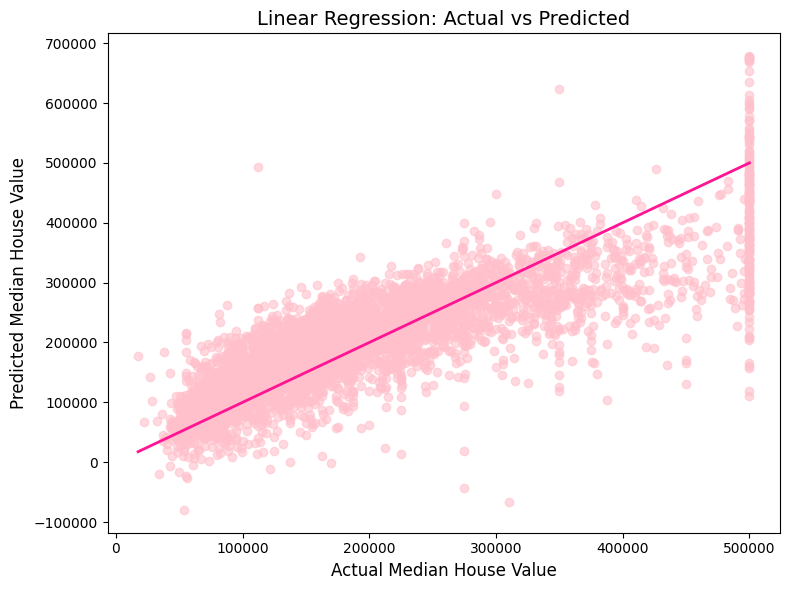

In [ ]:
import matplotlib.pyplot as plt
#plotting actual and predicted house prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='pink')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='deeppink',
    linewidth=2
)

plt.xlabel("Actual Median House Value", fontsize=12)
plt.ylabel("Predicted Median House Value", fontsize=12)
plt.title("Linear Regression: Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.show()

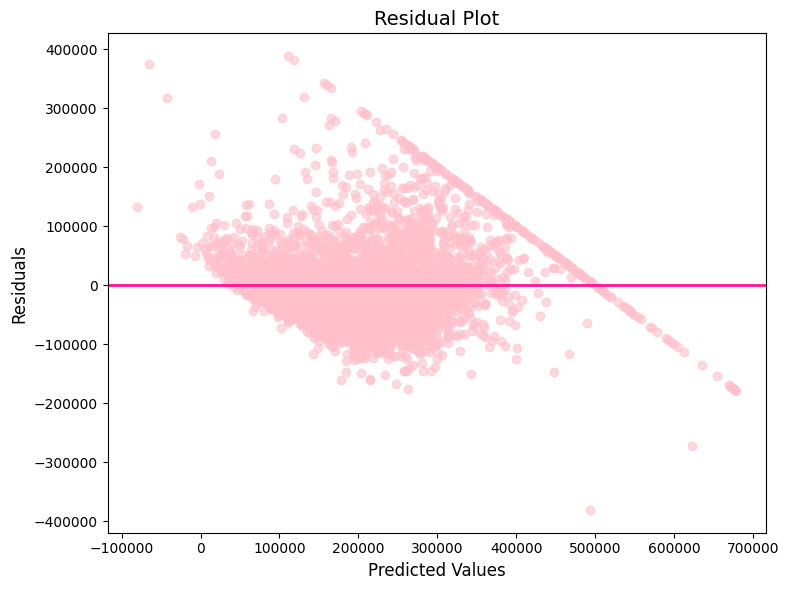

In [ ]:
residuals= y_test-y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6, color='pink')
plt.axhline(0, color='deeppink', linewidth=2)

plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residual Plot", fontsize=14)
plt.tight_layout()
plt.show()

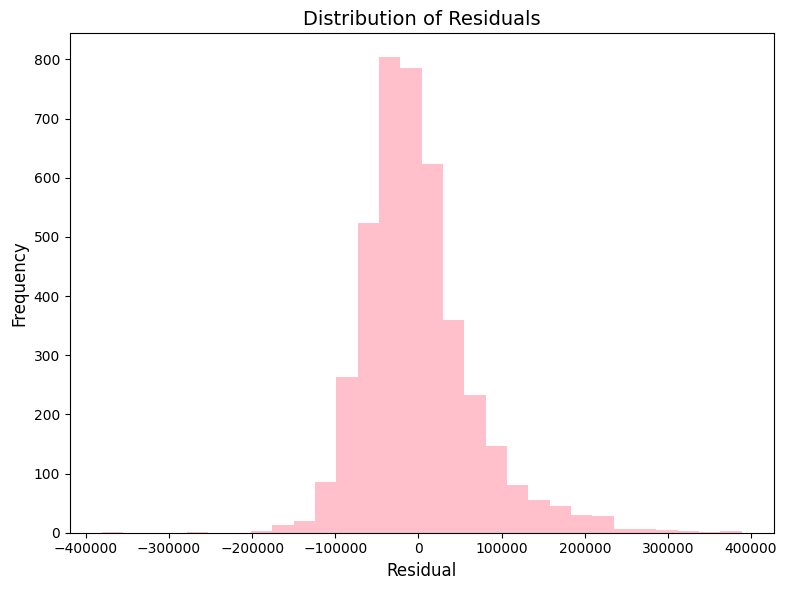

In [ ]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, color='pink')

plt.xlabel("Residual", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Residuals", fontsize=14)

plt.tight_layout()
plt.show()


The linear regression model is a supervised learning approach serving as a baseline to predict median house values in California using the California Housing datatset. We chose this as the baseline model because of its simplicity and interpretability when establishing a reference for comparison with more complex machine learning models. It was first cleaned by encoding the categorical variable and handling missing values, and then standardization. The dataset was divided into training and testing sets using a 75/25 split to evaluate the model's performance on generalizing unseen data.

The Actual vs. Predicted plot demonstrates the model's ability to approximate housing prices. Ideally, the predicted values would closely follow the diagnal reference line, which indicates high accuracy. In this plot, most data points are clustered around this line, meaning that the model captures general trends in housing price prediction well. However, some dispersion of the points, especially on the right, signifies that a linear model is not complex enough to fully capture and account for all the features which influence housing price prediction.

The Residual plot assesses the validity of the linear regression assumptions, which shows us that they were reasonably satisfied via the random scatter around zero. Besides the negative slope pattern, all other residuals appear randomly distributed, indicating no strong violation of linearity. Additionally, the residual distribution appears to be relatively normal, supporting the above statements. An advanced nonlinear model would likely result in better prediction accuracy.


Model performance was evaluated using RMSE and the coefficient of determination to measure prediction accuracy. The RMSE represents the average magnitude of prediction error for median house value. A lower value indicates better model performance. We also used R^2 to see that 64% of the variance in housing prices is explained by the model. The RMSE value of 69651.64 and
R^2 of 0.64 indicates that the linear regression baseline model is an adequate starting point, with room for improvement that can be accomplished with more complex nonlinear models.